# ReACT Agent Architecture

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="ReACT-Agent"

Tavily Tool

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()
tavily.invoke("Provide recent AI news for June 2029")

C:\Users\Dell\AppData\Local\Temp\ipykernel_7684\1418459558.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
C:\Users\Dell\AppData\Local\Temp\ipykernel_7684\1418459558.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'AI Insiders Weekly: Top Stories (June 29th Edition) - AI Leaders Council',
  'url': 'https://aileaderscouncil.org/ai-insiders-weekly-top-stories-june-29th-edition',
  'content': '## 1. Microsoft charts a different path for enterprise AI\n\nMicrosoft CEO Satya Nadella outlined a vision for enterprise AI that differs from many competitors. Rather than concentrating on increasingly expensive frontier models, Microsoft is emphasizing lower-cost models, customer choice, and giving organizations greater control over how AI is deployed inside their own environments.\n\nNadella argued that AI should augment employees rather than simply eliminate jobs. He described AI as a “knowledge engine” capable of helping organizations unlock the value of their own data while allowing businesses to choose from multiple models based on cost, performance, and governance requirements. [...] New Gartner research projects global AI spending will reach approximately $2.6 trillion this year, but the m

Arxiv Tool

In [3]:
import arxiv

def search_arxiv(query: str) -> str:
    """Search arxiv for research papers
    Args:
       Query: str
    Returns: str
    """
    client=arxiv.Client()
    search = arxiv.Search(
        query=query,
        max_results=2,
        sort_by=arxiv.SortCriterion.Relevance
    )
    output=[]
    for paper in client.results(search):
        output.append(
            f"""
Title: {paper.title}
Authors: {', '.join(a.name for a in paper.authors)}
Published: {paper.published.strftime('%Y-%m-%d')}
Summary:
{paper.summary[:500]}
PDF:
{paper.pdf_url}
"""
        )
        return "\n\n".join(output)

In [4]:
result = search_arxiv("Attention is all you need")
print(result)


Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Published: 2021-05-06
Summary:
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a
PDF:
https://arxiv.org/pdf/2105.02723v1



Wikipedia Tool

In [5]:
import wikipediaapi
import wikipedia
wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent = "pappu"
)
def search_wikipedia(query:str) -> str:
    """Seach wikipedia for a query and returns best matching article
    Args:
       Query: str
    Returns: str"""

    try:
        results=wikipedia.search(query)
        if not results:
            return "No matching Wikipedia articles found."
        
        page = wiki.page(results[0])

        return f"""
Title: {page.title}
Summary:
{page.summary[:500]}
URL:
{page.fullurl}
"""
    except Exception as e:
        return str(e)


Custom tools

In [8]:
def multiply(a:int, b:int) -> int:
    """Multiply a and b
    Args:
       a: first int
       b: second int
    """
    return a * b

def add(a:int, b:int) -> int:
    """Adds a and b
    Args:
      a: first int
      b: second int
    """
    return a + b

def divide(a:int, b:int) -> int:
    """Divide a and b
    Args:
      a: first int
      b: second int
    """
    return a / b

Tools collection

In [9]:
tools=[tavily,search_arxiv,search_wikipedia,add,multiply,divide]

Initializing the LLM

In [10]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
llm_with_tools = llm.bind_tools(tools)

Building the entire Chatbot w Langgraph

In [11]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

State Schema

In [13]:
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph.message import AnyMessage,add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

Main LLM Node

In [14]:
def tool_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

Building the graph

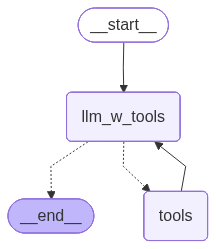

In [15]:
builder = StateGraph(State)

builder.add_node("llm_w_tools",tool_llm)
builder.add_node("tools",ToolNode(tools=tools))

builder.add_edge(START,"llm_w_tools")
builder.add_conditional_edges("llm_w_tools",tools_condition)
builder.add_edge("tools","llm_w_tools")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

invoking the llm and its tools

In [16]:
from pprint import pprint
# arxiv
result = graph.invoke({"messages":"What is attention is all you need"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is attention is all you need
================================== Ai Message ==================================
Tool Calls:
  search_arxiv (9d808swzc)
 Call ID: 9d808swzc
  Args:
    query: attention is all you need
================================= Tool Message =================================
Name: search_arxiv


Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Published: 2021-05-06
Summary:
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied o

In [17]:
# tavily
result = graph.invoke({"messages":"What is the current temperature in Goa"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is the current temperature in Goa
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (wrjbhxjms)
 Call ID: wrjbhxjms
  Args:
    query: current temperature in Goa
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Goa Weather Conditions: Temperature | 30 Days Forecast", "url": "https://www.aqi.in/weather/india/goa", "content": "9.\n\nIndia flagAkbarpur, Uttar Pradesh\n\nIndia flag\n\n36 °C\n\nsmoky hazeSmoky haze\n\nsmoky haze\n\nHumidity Icon47%\n\nHumidity Icon\n\nUV Icon4.6\n\nUV Icon\n\n13.3 kmph /  E\n\n10.\n\nIndia flagSasaram, Bihar\n\nIndia flag\n\n36 °C\n\npartly cloudyPartly Cloudy\n\npartly cloudy\n\nHumidity Icon46%\n\nHumidity Icon\n\nUV Icon5.5\n\nUV Icon\n\n12.2 kmph /  E\n\nLast Updated:  02 Jul 2026, 04:04 AM\n\n## FAQs About Goa Weather C

In [18]:
# wikipedia
result = graph.invoke({"messages":"Tell me something about Steve Jobs"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

Tell me something about Steve Jobs
================================== Ai Message ==================================
Tool Calls:
  search_wikipedia (ygzkj67xh)
 Call ID: ygzkj67xh
  Args:
    query: Steve Jobs
================================= Tool Message =================================
Name: search_wikipedia

Expecting value: line 1 column 1 (char 0)
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (4rh27h3bp)
 Call ID: 4rh27h3bp
  Args:
    query: Steve Jobs
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Steve Jobs: Biography, Apple Cofounder, Entrepreneur", "url": "https://www.biography.com/business-leaders/steve-jobs", "content": "> 1955-2011\n\n## Who Was Steve Jobs?\n\nSteve Jobs was an American inventor, designer, and entrepreneur who was the cof

In [ ]:
# llm only
result = graph.invoke({"messages":"What is machine learning ?"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is machine learning ?
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead, these systems learn patterns and make decisions based on data. Key aspects include:

1. **Learning from Data**: Algorithms improve their performance as they are exposed to more data, identifying patterns or relationships within it.
2. **Types of Learning**:
   - **Supervised Learning**: Uses labeled data to train models (e.g., predicting house prices based on features like size and location).
   - **Unsupervised Learning**: Finds hidden structures in unlabeled data (e.g., clustering customers into groups).
   - **Reinforcement Learning**: Learns by interacting with an environment to maximize rewards (

Multiple tool call (tavily plus custom add function)

In [19]:
# llm only
result = graph.invoke({"messages":"What is 5+5 and then multiply it by 10?"})
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 5+5 and then multiply it by 10?
================================== Ai Message ==================================
Tool Calls:
  add (gf7m8rzm0)
 Call ID: gf7m8rzm0
  Args:
    a: 5
    b: 5
  multiply (2mp1f2ge2)
 Call ID: 2mp1f2ge2
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: add

10
================================= Tool Message =================================
Name: multiply

100
================================== Ai Message ==================================

The result of 5 + 5 is 10. Multiplying that by 10 gives:

**10 × 10 = 100**

Final answer: **100**


# Agent Memory

to hold conversation context

recompiling grpah with memory saver

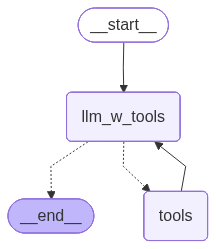

In [20]:
builder = StateGraph(State)

builder.add_node("llm_w_tools",tool_llm)
builder.add_node("tools",ToolNode(tools=tools))

builder.add_edge(START,"llm_w_tools")
builder.add_conditional_edges("llm_w_tools",tools_condition)
builder.add_edge("tools","llm_w_tools")

# memory saver
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_w_memory = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

specifiying a thread which holds the checkpoints

In [21]:
config={"configurable":{"thread_id":"1"}}

testing out the memory graph

In [ ]:
# adding 5+5
result = graph_w_memory.invoke({"messages":"What is 5+5"},config=config)
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 5+5
================================== Ai Message ==================================
Tool Calls:
  add (43pbssr7c)
 Call ID: 43pbssr7c
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================

The result of 5 + 5 is **10**.


In [24]:
# adding 25 to that total
result = graph_w_memory.invoke({"messages":"add that number to 25"},config=config)
for msg in result['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 5+5
================================== Ai Message ==================================
Tool Calls:
  add (43pbssr7c)
 Call ID: 43pbssr7c
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================

The result of 5 + 5 is **10**.
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (hpacfx3vk)
 Call ID: hpacfx3vk
  Args:
    a: 10
    b: 25
================================= Tool Message =================================
Name: add

35
================================== Ai Message ==================================

The final result is $\boxed{35}$.
